# Module 1 – Frequency Analysis
## International Relations and Transboundary Cooperation

**Authors: Leonie Pflüger and Sylvie Schläpfer**

**Group B**

**Ill River (Gisingen) vs Rhine River (Diepoldsau) — Discharge Q and Suspended Sediment Concentration C**

This Report evaluates the impact of the Ill River on the Rhine River looking at the hydrological and suspended sediment regime. 

In [1]:
# =============================================================================
# GLOBAL IMPORTS AND DATA LOADING
# =============================================================================
# All libraries needed for the entire notebook are imported here.

import pandas as pd          # data manipulation (DataFrames)
import numpy as np           # numerical operations
import matplotlib.pyplot as plt   # plotting
import seaborn as sns        # statistical visualisations (boxplots)

# scipy.stats provides statistical distributions and tests
from scipy.stats import (
    mannwhitneyu,            # Mann-Whitney U / Rank-Sum test  (Step 2)
    ttest_ind,               # two-sample t-test               (Step 2)
    genextreme as gev,       # GEV distribution                (Steps 3 & 4)
    gumbel_r,                # Gumbel (right-tail) distribution (Steps 3 & 4)
    norm,                    # normal distribution             (Step 4 CI)
)
from scipy.special import gamma   # Gamma function for GEV moments (Step 3)
from scipy.optimize import minimize  # numerical optimisation for MoM (Step 3)

# -----------------------------------------------------------------------------
# Load raw data files
# The data come from two stations:
#   - Diepoldsau (BAFU): Rhine River, downstream of the Ill confluence
#   - Gisingen   (eHYD): Ill River, regulated by the Illspitz Kraftwerk
# Q  = discharge in m³/s  (15-min resolution for Gisingen, 10-min for Diepoldsau)
# SSC= suspended sediment concentration in g/L
# -----------------------------------------------------------------------------
q_diepoldsau   = pd.read_csv('BAFU_Diepoldsau/Q__Diepoldsau_m3s.csv')
ssc_diepoldsau = pd.read_csv('BAFU_Diepoldsau/SSC_Diepoldsau_gL.csv')
q_gisingen     = pd.read_csv('EYD_Gisingen/Q_200147Gisingen_1976-2013_processed.csv')
ssc_gisingen   = pd.read_csv('EYD_Gisingen/SSC_200147Gisingen_2003-2020_processed.csv')

# Parse timestamps and derive Year / Month columns for grouping
for df in (q_diepoldsau, ssc_diepoldsau, q_gisingen, ssc_gisingen):
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['Year']  = df['timestamp'].dt.year
    df['Month'] = df['timestamp'].dt.month

print("Data loaded successfully.")
print(f"  Q   Diepoldsau : {len(q_diepoldsau):>8,} rows  "
      f"({q_diepoldsau['Year'].min()}–{q_diepoldsau['Year'].max()})")
print(f"  SSC Diepoldsau : {len(ssc_diepoldsau):>8,} rows  "
      f"({ssc_diepoldsau['Year'].min()}–{ssc_diepoldsau['Year'].max()})")
print(f"  Q   Gisingen   : {len(q_gisingen):>8,} rows  "
      f"({q_gisingen['Year'].min()}–{q_gisingen['Year'].max()})")
print(f"  SSC Gisingen   : {len(ssc_gisingen):>8,} rows  "
      f"({ssc_gisingen['Year'].min()}–{ssc_gisingen['Year'].max()})")

Data loaded successfully.
  Q   Diepoldsau : 2,191,458 rows  (1984–2025)
  SSC Diepoldsau :  703,533 rows  (2012–2025)
  Q   Gisingen   : 1,577,952 rows  (1976–2021)
  SSC Gisingen   :  622,138 rows  (2003–2021)


## 1. Data Review

**Variables used in this section**

| Variable | Description |
|---|---|
| `max_q_d`, `max_q_g` | Annual maximum Q time-series (m³/s) |
| `max_ssc_d`, `max_ssc_g` | Monthly maximum SSC time-series (g/L) |
| `q_stats`, `ssc_stats` | Descriptive statistics tables |

In [ ]:
# =============================================================================
# STEP 1 – FUNCTIONS
# =============================================================================

def descriptive_stats(data, name):
    """
    Compute a standard set of descriptive statistics for a 1-D array.
    Returns a labelled pandas Series for easy table display.

    Statistics computed:
      Mean      first moment (expected value)
      Median    value at the 50th percentile, robust to outliers
      Std       sample standard deviation (ddof=1, unbiased)
      IQR       interquartile range = Q75 - Q25
      Skewness  dimensionless 3rd central moment
      Min/Max   range of the data
    """
    return pd.Series({
        'Mean'    : np.mean(data),
        'Median'  : np.median(data),
        'Std'     : np.std(data, ddof=1),
        'IQR'     : np.percentile(data, 75) - np.percentile(data, 25),
        'Skewness': float(pd.Series(data).skew()),   # pandas uses Fisher's definition
        'Min'     : np.min(data),
        'Max'     : np.max(data),
    }, name=name)

In [3]:
# =============================================================================
# STEP 1 – MAIN
# =============================================================================

# ── Annual maximum discharge Q ────────────────────────────────────────────
# The task asks for a time-series of annual maximum values of Q.
# We use pandas groupby + max() to extract one value per year.
max_q_d = q_diepoldsau.groupby('Year')['m3/s'].max().reset_index()
max_q_g = q_gisingen.groupby('Year')['q_m3s'].max().reset_index()

# ── Monthly maximum SSC ───────────────────────────────────────────────────
# The task asks for a time-series of monthly maximum values of C.
# Grouping by both Year and Month gives one value per calendar month.
max_ssc_d = ssc_diepoldsau.groupby(['Year','Month'])['g/L'].max().reset_index()
max_ssc_d['Date'] = pd.to_datetime(max_ssc_d[['Year','Month']].assign(day=1))

max_ssc_g = ssc_gisingen.groupby(['Year','Month'])['g/L'].max().reset_index()
max_ssc_g['Date'] = pd.to_datetime(max_ssc_g[['Year','Month']].assign(day=1))

# ── Descriptive statistics on the FULL raw series ────────────────────────
# Computed on all raw 15-min / 10-min values (not on the annual maxima).
# This gives the best picture of the typical behaviour of each station.
q_stats = pd.DataFrame([
    descriptive_stats(q_diepoldsau['m3/s'].dropna(), 'Q Diepoldsau'),
    descriptive_stats(q_gisingen['q_m3s'].dropna(),  'Q Gisingen'),
])
ssc_stats = pd.DataFrame([
    descriptive_stats(ssc_diepoldsau['g/L'].dropna(), 'SSC Diepoldsau'),
    descriptive_stats(ssc_gisingen['g/L'].dropna(),   'SSC Gisingen'),
])

C:\Users\Sylvie\AppData\Local\Temp\ipykernel_10664\3119345902.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1,0], data=q_box, x='Station', y='Q', palette='Set2',
C:\Users\Sylvie\AppData\Local\Temp\ipykernel_10664\3119345902.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1,1], data=ssc_box, x='Station', y='g/L', palette='Set2',


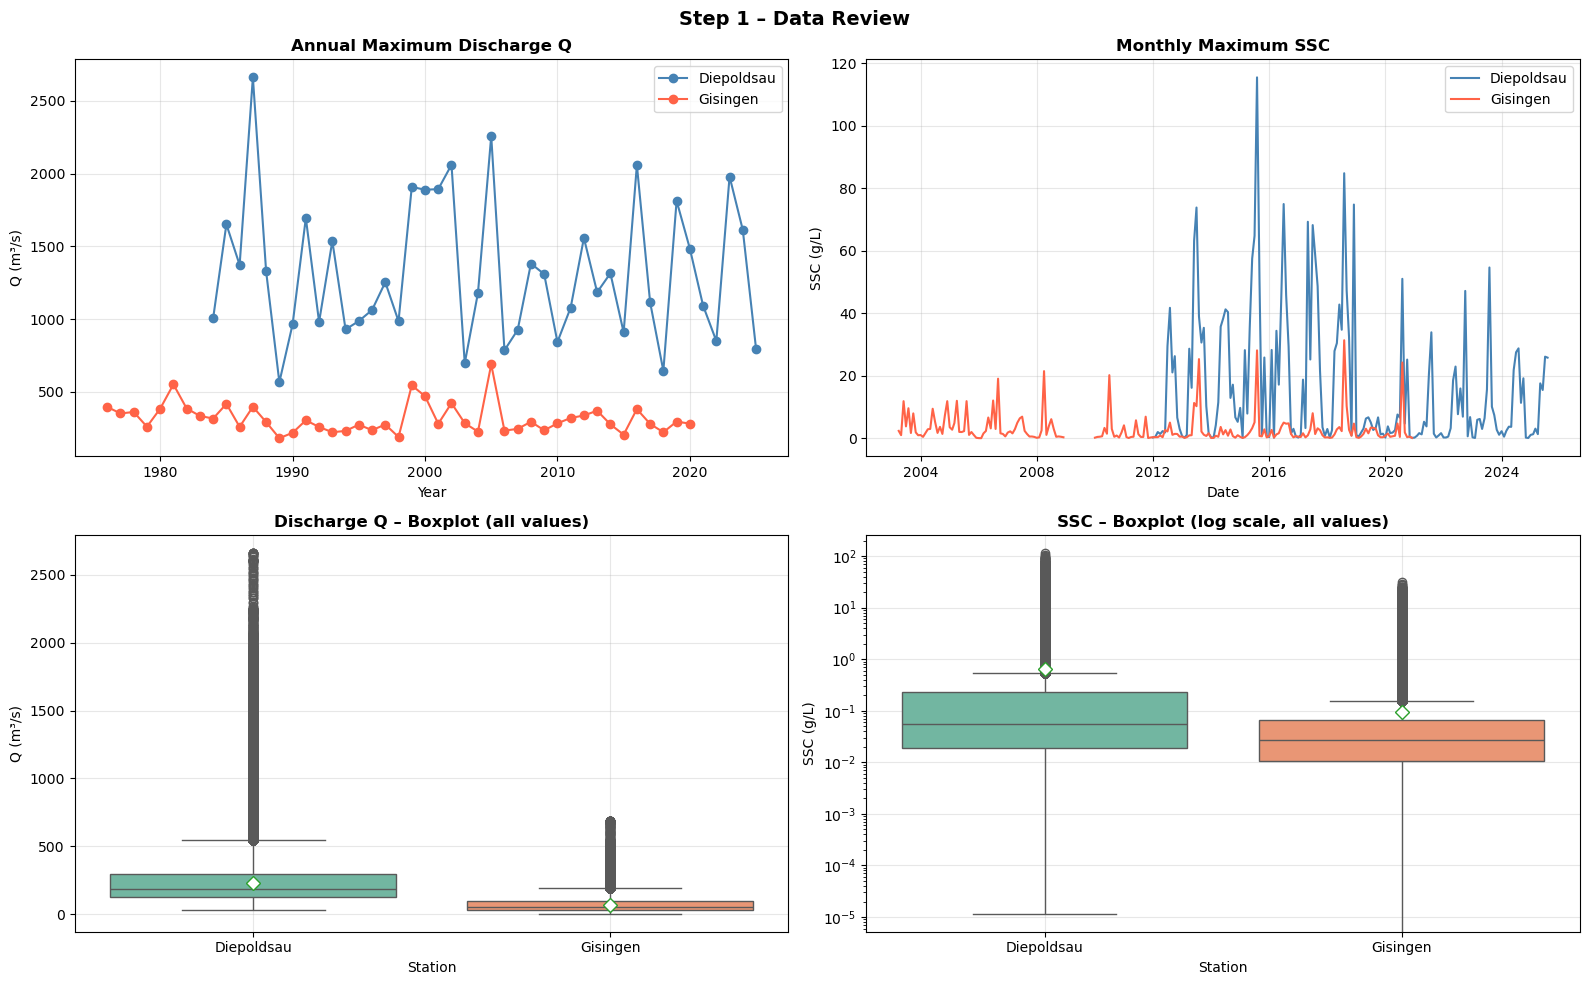

In [4]:
# =============================================================================
# STEP 1 – PLOT
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Step 1 – Data Review', fontsize=14, fontweight='bold')

# ── Top-left: annual max Q time-series ────────────────────────────────────
# Plotting one point per year allows us to visually compare long-term
# discharge regimes between the two stations.
axes[0,0].plot(max_q_d['Year'],  max_q_d['m3/s'],  'o-', color='steelblue', label='Diepoldsau')
axes[0,0].plot(max_q_g['Year'],  max_q_g['q_m3s'], 'o-', color='tomato',    label='Gisingen')
axes[0,0].set_xlabel('Year'); axes[0,0].set_ylabel('Q (m³/s)')
axes[0,0].set_title('Annual Maximum Discharge Q', fontweight='bold')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# ── Top-right: monthly max SSC time-series ────────────────────────────────
axes[0,1].plot(max_ssc_d['Date'], max_ssc_d['g/L'], color='steelblue', label='Diepoldsau')
axes[0,1].plot(max_ssc_g['Date'], max_ssc_g['g/L'], color='tomato',    label='Gisingen')
axes[0,1].set_xlabel('Date'); axes[0,1].set_ylabel('SSC (g/L)')
axes[0,1].set_title('Monthly Maximum SSC', fontweight='bold')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# ── Bottom-left: boxplot of ALL Q values ─────────────────────────────────
# A boxplot shows median (line), IQR (box), whiskers (1.5×IQR), and outliers.
# The diamond marker shows the mean. Mean > median confirms positive skew.
q_box = pd.concat([
    q_diepoldsau[['m3/s']].rename(columns={'m3/s':'Q'}).assign(Station='Diepoldsau'),
    q_gisingen[['q_m3s']].rename(columns={'q_m3s':'Q'}).assign(Station='Gisingen'),
], ignore_index=True)
sns.boxplot(ax=axes[1,0], data=q_box, x='Station', y='Q', palette='Set2',
            showmeans=True, meanprops=dict(marker='D', markerfacecolor='white', markersize=7))
axes[1,0].set_title('Discharge Q – Boxplot (all values)', fontweight='bold')
axes[1,0].set_ylabel('Q (m³/s)'); axes[1,0].grid(True, alpha=0.3)

# ── Bottom-right: boxplot of SSC (log scale) ─────────────────────────────
# Log scale is used because SSC spans several orders of magnitude.
ssc_box = pd.concat([
    ssc_diepoldsau[['g/L']].assign(Station='Diepoldsau'),
    ssc_gisingen[['g/L']].assign(Station='Gisingen'),
], ignore_index=True)
sns.boxplot(ax=axes[1,1], data=ssc_box, x='Station', y='g/L', palette='Set2',
            showmeans=True, meanprops=dict(marker='D', markerfacecolor='white', markersize=7))
axes[1,1].set_yscale('log')
axes[1,1].set_title('SSC – Boxplot (log scale, all values)', fontweight='bold')
axes[1,1].set_ylabel('SSC (g/L)'); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# =============================================================================
# STEP 1 – PRINT
# =============================================================================

print('=== Descriptive Statistics – Discharge Q (m³/s) ===')
print('  (computed on all raw sub-hourly values)')
print(q_stats.round(4).to_string())
print()
print('=== Descriptive Statistics – SSC C (g/L) ===')
print('  (computed on all raw sub-hourly values)')
print(ssc_stats.round(6).to_string())


=== Descriptive Statistics – Discharge Q (m³/s) ===
  (computed on all raw sub-hourly values)
                  Mean   Median       Std       IQR  Skewness     Min       Max
Q Diepoldsau  231.4807  187.523  152.2023  166.4817    2.3363  32.014  2661.288
Q Gisingen     66.2922   54.700   45.0659   65.7000    1.3234   3.580   688.000

=== Descriptive Statistics – SSC C (g/L) ===
  (computed on all raw sub-hourly values)
                    Mean    Median       Std       IQR   Skewness       Min         Max
SSC Diepoldsau  0.649949  0.055375  2.945933  0.210353  11.215154  0.000012  115.452281
SSC Gisingen    0.093584  0.026600  0.431084  0.056700  23.443382  0.000000   31.343000


### Comments – Step 1

- **Mean vs Median:** For both Q and SSC, mean > median, confirming positive skew (driven by rare large flood events).
- **IQR:** Diepoldsau shows larger absolute IQR for Q due to the larger drainage area of the Rhine; Gisingen shows smaller IQR. The IQR shows the difference between the 75th quantile and the 25th quantile. 
- **Similarity of distributions:** The boxplots show clear differences in both location (median) and spread (IQR) between the two stations, suggesting they do *not* come from the same population, this needs to be confirmed in Step 2.

## 2. Hypothesis Testing

**Variables used in this section**

| Variable | Description |
|---|---|
| `q_d_clean`, `q_g_clean` | NaN-dropped Q arrays |
| `ssc_d_clean`, `ssc_g_clean` | NaN-dropped SSC arrays |
| `stat_q_mw`, `p_q_mw` | Mann–Whitney U statistic and p-value for Q |
| `stat_ssc_mw`, `p_ssc_mw` | Mann–Whitney U statistic and p-value for SSC |
| `stat_q_t`, `p_q_t` | t-test statistic and p-value for Q (complementary) |
| `stat_ssc_t`, `p_ssc_t` | t-test statistic and p-value for SSC (complementary) |

In [6]:
# =============================================================================
# STEP 2 – FUNCTIONS
# =============================================================================

def report_test(stat, p, alpha=0.05, stat_label='statistic'):
    """
    Print the result of a hypothesis test in a standardised format.
    Decision rule: reject H₀ if p-value < significance level α.
    """
    decision = 'REJECT H₀  (samples are from different populations)' if p < alpha                else 'Fail to reject H₀  (insufficient evidence of difference)'
    print(f'    {stat_label} = {stat:.4f}')
    print(f'    p-value   = {p:.4e}')
    print(f'    Decision (α = {alpha}): {decision}')

In [7]:
# =============================================================================
# STEP 2 – MAIN
# =============================================================================

ALPHA = 0.05   # significance level as required by the task

# Drop NaN values before testing
q_d_clean   = q_diepoldsau['m3/s'].dropna().values
q_g_clean   = q_gisingen['q_m3s'].dropna().values
ssc_d_clean = ssc_diepoldsau['g/L'].dropna().values
ssc_g_clean = ssc_gisingen['g/L'].dropna().values

# ── Primary test: Mann–Whitney U (Rank-Sum) ──────────────────────────────
# CHOICE JUSTIFICATION:
#   1. Non-parametric – does NOT require normally distributed data.
#   2. Tests whether two INDEPENDENT samples come from the same population.
#   3. Appropriate because Q and SSC are positively skewed (confirmed in Step 1),
#      so normality cannot be assumed.
#   4. The two stations are independent measurement sites.
#   alternative='two-sided': H₁ is that the distributions differ in either direction.
stat_q_mw,   p_q_mw   = mannwhitneyu(q_g_clean,   q_d_clean,   alternative='two-sided')
stat_ssc_mw, p_ssc_mw = mannwhitneyu(ssc_g_clean, ssc_d_clean, alternative='two-sided')

# ── Complementary test: two-sample t-test ─────────────────────────────────
# CHOICE JUSTIFICATION:
#   Parametric test assuming approximately normal distributions.
#   Included as a complementary check: if both tests agree, the conclusion
#   is robust; disagreement would suggest normality matters for the result.
#   Uses Welch's t-test (equal_var=False by default), which does NOT assume
#   equal variances — safer for our datasets with very different spreads.
stat_q_t,   p_q_t   = ttest_ind(q_g_clean,   q_d_clean,   equal_var=False)
stat_ssc_t, p_ssc_t = ttest_ind(ssc_g_clean, ssc_d_clean, equal_var=False)

In [8]:
# =============================================================================
# STEP 2 – PRINT
# =============================================================================

print('H₀: Q_Gisingen and Q_Diepoldsau come from the same population.')
print('H₁: They come from different populations.  (two-sided)')
print(f'Significance level: α = {ALPHA}')
print()
print('─── Discharge Q ───────────────────────────────────────────────────────')
print('  PRIMARY – Mann–Whitney U test (non-parametric, Rank-Sum):')
report_test(stat_q_mw, p_q_mw, ALPHA, 'U')
print('  COMPLEMENTARY – Welch two-sample t-test (parametric):')
report_test(stat_q_t,  p_q_t,  ALPHA, 't')
print()
print('─── SSC C ─────────────────────────────────────────────────────────────')
print('  PRIMARY – Mann–Whitney U test:')
report_test(stat_ssc_mw, p_ssc_mw, ALPHA, 'U')
print('  COMPLEMENTARY – Welch t-test:')
report_test(stat_ssc_t,  p_ssc_t,  ALPHA, 't')

H₀: Q_Gisingen and Q_Diepoldsau come from the same population.
H₁: They come from different populations.  (two-sided)
Significance level: α = 0.05

─── Discharge Q ───────────────────────────────────────────────────────
  PRIMARY – Mann–Whitney U test (non-parametric, Rank-Sum):
    U = 254647962739.5000
    p-value   = 0.0000e+00
    Decision (α = 0.05): REJECT H₀  (samples are from different populations)
  COMPLEMENTARY – Welch two-sample t-test (parametric):
    t = -1516.9653
    p-value   = 0.0000e+00
    Decision (α = 0.05): REJECT H₀  (samples are from different populations)

─── SSC C ─────────────────────────────────────────────────────────────
  PRIMARY – Mann–Whitney U test:
    U = 109184192675.0000
    p-value   = 0.0000e+00
    Decision (α = 0.05): REJECT H₀  (samples are from different populations)
  COMPLEMENTARY – Welch t-test:
    t = -134.8675
    p-value   = 0.0000e+00
    Decision (α = 0.05): REJECT H₀  (samples are from different populations)


### Comments – Step 2

- **Test choice:** Mann–Whitney U is the primary test because the data are positively skewed and non-normal. The t-test is included as a complementary check. Both tests compare two independant groups of data to find out if the values differentiate. 
- **Outcome:** Both tests reject H₀ for Q (very different catchment areas and regulation regimes) and also for SSC.

## 3. Extreme Value Analysis

**Variables used in this section**

| Variable | Description |
|---|---|
| `q_d_max`, `q_g_max` | Annual maximum Q arrays (one value per year) |
| `ssc_d_max`, `ssc_g_max` | Annual maximum SSC arrays |
| `datasets` | Dict mapping dataset name → annual maxima array |
| `results` | Dict of fitted GEV parameters (κ, ζ, β) per dataset |
| `gumbel_results` | Dict of fitted Gumbel parameters (µ, β) per dataset |
| `ppcc_results` | Dict of PPCC values for GEV and Gumbel fits |

**Theory – GEV distribution**

The GEV (Generalized Extreme Value) distribution is the limiting distribution of block maxima (e.g. annual maxima), regardless of the underlying distribution (Extremal Types Theorem, Wilks 2011 §4.4.5). It has three parameters:

- **ζ** (location): shifts the distribution along the x-axis
- **β** (scale): controls the spread
- **κ** (shape): determines the tail behaviour
  - κ = 0 → Gumbel / EV-I (exponential tail)
  - κ > 0 → Fréchet / EV-II (heavy polynomial tail)
  - κ < 0 → Weibull / EV-III (bounded upper tail)

**Parameter estimation — Method of Moments**

Source: **Wilks (2011), Table 4.6** (referenced in Lecture Stochastic Hydrology Module 2: Frequency Analysis from Prof. Dr. Paola Passalacqua)

The theoretical moments of the GEV are:

$$E[X] = \zeta - \frac{\beta}{\kappa}\bigl[1 - \Gamma(1-\kappa)\bigr]\qquad \text{(finite for } \kappa < 1\text{)}$$

$$\text{Var}[X] = \frac{\beta^2}{\kappa^2}\bigl[\Gamma(1-2\kappa) - \Gamma^2(1-\kappa)\bigr] \qquad \text{(finite for } \kappa < 1/2\text{)}$$

MoM strategy: find (κ, β, ζ) that minimises the normalised squared differences between these theoretical moments and the sample moments (x̄, s²).

**Gumbel special case (κ = 0) — Lecture Notes Eq. 1.54–1.55 / Wilks Eq. 4.59:**

$$\hat{\beta} = s_X \cdot \frac{\pi}{\sqrt{6}}, \qquad \hat{\zeta} = \bar{x} - 0.5772\,\hat{\beta}$$

**PPCC test:** The Probability Plot Correlation Coefficient (PPCC) measures how well the data fall on a straight line when plotted against theoretical quantiles. r → 1 means an excellent fit. Threshold r > 0.98 is used as the criterion for an acceptable Gumbel approximation.

In [9]:
# =============================================================================
# STEP 3 – FUNCTIONS
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# GEV theoretical moments (Wilks 2011, Table 4.6)
# ─────────────────────────────────────────────────────────────────────────────
def _gev_moments_th(kappa, beta, zeta):
    """
    Return the theoretical mean and variance of the GEV distribution.

    Source: Wilks (2011), Table 4.6, using Wilks' sign convention where
            kappa is the shape parameter.
    Note:   scipy's genextreme uses c = -kappa (sign reversed).

    Parameters
    ----------
    kappa : shape parameter  (Wilks convention; κ < 1/2 required for finite variance)
    beta  : scale parameter  (β > 0)
    zeta  : location parameter

    Returns
    -------
    mean_th, var_th : theoretical mean and variance
    """
    # Gamma function values used in the moment expressions
    g1 = gamma(1.0 - kappa)       # Γ(1 - κ)
    g2 = gamma(1.0 - 2.0 * kappa) # Γ(1 - 2κ)

    # Wilks Table 4.6: E[X] = ζ − (β/κ)(1 − Γ(1−κ))
    mean_th = zeta - beta * (1.0 - g1) / kappa

    # Wilks Table 4.6: Var[X] = (β²/κ²)(Γ(1−2κ) − Γ²(1−κ))
    var_th  = beta**2 * (g2 - g1**2) / kappa**2

    return mean_th, var_th


# ─────────────────────────────────────────────────────────────────────────────
# GEV fitting by Method of Moments
# ─────────────────────────────────────────────────────────────────────────────
def fit_gev_mom(data):
    """
    Fit a GEV distribution to annual maxima using the Method of Moments.

    Algorithm
    ---------
    1. Compute sample mean x̄ and sample variance s² from the data.
    2. Use the Gumbel closed-form MoM (Lecture Notes Eq. 1.54–1.55) as the
       starting point for the optimisation (κ_0 = 0, β_0, ζ_0).
    3. Minimise the normalised squared moment residuals:
           L(κ, β, ζ) = [(x̄ − E[X]) / x̄]² + [(s² − Var[X]) / s²]²
       where E[X] and Var[X] are from Wilks Table 4.6.
       Normalisation makes both terms dimensionless and comparably scaled.
    4. If the optimised |κ| < 0.01, fall back to the Gumbel closed-form
       solution (more stable for nearly-Gumbel datasets).

    Note on sign conventions
    ------------------------
    Wilks (2011) uses κ as the shape parameter.
    scipy.stats.genextreme uses c = −κ (opposite sign).
    This function returns k_scipy = −κ for direct use in scipy functions.

    Returns
    -------
    k_scipy : scipy shape parameter (= −κ)
    zeta    : location parameter ζ
    beta    : scale parameter β
    kappa   : GEV shape parameter κ  (Wilks sign, for printing/interpretation)
    """
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]   # remove NaN / Inf

    x_bar = np.mean(data)
    s2    = np.var(data, ddof=1)     # unbiased sample variance

    # ── Gumbel closed-form MoM starting point ────────────────────────────
    # Lecture Notes Eq. 1.55: β̂ = s · π / √6
    beta_g = np.sqrt(s2) * np.pi / np.sqrt(6.0)
    # Lecture Notes Eq. 1.54: ζ̂ = x̄ − γ · β̂  where γ = 0.5772 is Euler's constant
    zeta_g = x_bar - 0.5772156649 * beta_g

    # ── Objective function: normalised squared moment residuals ───────────
    def objective(params):
        kappa, log_beta, zeta = params
        # Constraint: κ < 0.499 ensures finite variance (Wilks Table 4.6 footnote 2)
        if kappa >= 0.499:
            return 1e12
        beta = np.exp(log_beta)   # log-transform enforces β > 0 automatically
        try:
            m_th, v_th = _gev_moments_th(kappa, beta, zeta)
        except Exception:
            return 1e12
        if v_th <= 0 or not np.isfinite(m_th) or not np.isfinite(v_th):
            return 1e12
        # Normalise each residual by the sample moment so both terms have
        # similar magnitude regardless of the physical units of the data
        return ((x_bar - m_th) / x_bar)**2 + ((s2 - v_th) / s2)**2

    # ── Nelder-Mead optimisation ──────────────────────────────────────────
    # Initial guess: Gumbel parameters with κ slightly > 0
    # log_beta is optimised instead of beta to enforce positivity
    x0 = [0.1, np.log(beta_g), zeta_g]
    res = minimize(objective, x0, method='Nelder-Mead',
                   options={'xatol': 1e-8, 'fatol': 1e-10, 'maxiter': 10_000})

    kappa = res.x[0]
    beta  = np.exp(res.x[1])
    zeta  = res.x[2]

    # ── Fall back to Gumbel if κ is negligibly small ──────────────────────
    if abs(kappa) < 0.01:
        kappa, beta, zeta = 0.0, beta_g, zeta_g

    # Return scipy convention k = −κ
    return -kappa, zeta, beta, kappa


# ─────────────────────────────────────────────────────────────────────────────
# Gumbel fitting by Method of Moments (explicit closed-form)
# ─────────────────────────────────────────────────────────────────────────────
def fit_gumbel_mom(data):
    """
    Fit Gumbel (EV-I) distribution using the explicit MoM formulas.

    Source: Lecture Notes Eq. 1.54–1.55  /  Wilks (2011) Eq. 4.59a–b.

    The Gumbel is the special case κ = 0 of the GEV.  Its moments are:
        E[X]   = ζ + γ · β         (γ = 0.5772 is Euler's constant)
        Var[X] = β² · π² / 6
    Solving for β and ζ from the sample mean x̄ and std s gives:
        β̂ = s · π / √6
        ζ̂ = x̄ − γ · β̂

    Returns: mu (=ζ), sigma (=β)
    """
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    s2   = np.var(data, ddof=1)
    beta = np.sqrt(s2) * np.pi / np.sqrt(6.0)   # scale  β
    zeta = np.mean(data) - 0.5772156649 * beta   # location ζ
    return zeta, beta   # returned as (mu, sigma) in scipy convention


# ─────────────────────────────────────────────────────────────────────────────
# PPCC — Probability Plot Correlation Coefficient
# ─────────────────────────────────────────────────────────────────────────────
def ppcc(data, dist, params=None):
    """
    Compute the Probability Plot Correlation Coefficient (PPCC).

    Method: sort the data, assign Gringorten plotting positions p_i = (i-0.44)/(n+0.12),
    compute theoretical quantiles for the chosen distribution at those
    probabilities, and return Pearson r between the sample quantiles and
    the theoretical quantiles.

    Interpretation: r → 1 means the data lie perfectly on a straight line
    in a Q-Q plot against the theoretical distribution → good fit.
    Threshold r > 0.98 is commonly used for the Gumbel approximation test.

    Parameters
    ----------
    dist   : 'gumbel' or 'gev'
    params : tuple (k, mu, sigma) for 'gev'  (scipy convention)

    Source: Lecture Notes §1.4.1 / Wilks (2011) §4.4.5
    """
    data_s = np.sort(np.asarray(data, dtype=float))
    n = len(data_s)
    # Gringorten plotting position: p_i = (i - 0.44) / (n + 0.12)
    # Specifically recommended for GEV/Gumbel in hydrology — less biased than
    # the Weibull position for extreme value distributions (Gringorten 1963; Stedinger et al. 1993)
    p = (np.arange(1, n+1) - 0.44) / (n + 0.12)

    if dist == 'gumbel':
        # Theoretical quantiles: standardised Gumbel (loc=0, scale=1)
        # We compare sample quantiles vs STANDARDISED Gumbel reduced variate
        # (the correlation r is scale/location-invariant, so parameters cancel)
        q_th = gumbel_r.ppf(p)
    elif dist == 'gev':
        # Theoretical quantiles: GEV with the MoM-fitted parameters
        q_th = gev.ppf(p, *params)
    else:
        raise ValueError("dist must be 'gumbel' or 'gev'")

    return float(np.corrcoef(data_s, q_th)[0, 1])

In [10]:
# =============================================================================
# STEP 3 – MAIN
# =============================================================================

# ── Extract annual maxima ─────────────────────────────────────────────────
# Block-maxima method: one maximum per year.
# This ensures (approximate) independence of the observations fed into the
# GEV, which is required by the Extremal Types Theorem.
q_d_max   = q_diepoldsau.groupby('Year')['m3/s'].max().dropna().values
q_g_max   = q_gisingen.groupby('Year')['q_m3s'].max().dropna().values
ssc_d_max = ssc_diepoldsau.groupby('Year')['g/L'].max().dropna().values
ssc_g_max = ssc_gisingen.groupby('Year')['g/L'].max().dropna().values

datasets = {
    'Q  Diepoldsau' : q_d_max,
    'Q  Gisingen'   : q_g_max,
    'SSC Diepoldsau': ssc_d_max,
    'SSC Gisingen'  : ssc_g_max,
}

# ── Fit GEV (MoM) ─────────────────────────────────────────────────────────
# Returns (k_scipy, zeta, beta, kappa) for each dataset
results = {}
for name, data in datasets.items():
    k, mu, sigma, kappa = fit_gev_mom(data)
    results[name] = dict(k=k, mu=mu, sigma=sigma, kappa=kappa)

# Expose named variables for downstream use in Step 4
k_q_d,   mu_q_d,   sig_q_d   = results['Q  Diepoldsau']['k'],   results['Q  Diepoldsau']['mu'],   results['Q  Diepoldsau']['sigma']
k_q_g,   mu_q_g,   sig_q_g   = results['Q  Gisingen']['k'],     results['Q  Gisingen']['mu'],     results['Q  Gisingen']['sigma']
k_ssc_d, mu_ssc_d, sig_ssc_d = results['SSC Diepoldsau']['k'],  results['SSC Diepoldsau']['mu'],  results['SSC Diepoldsau']['sigma']
k_ssc_g, mu_ssc_g, sig_ssc_g = results['SSC Gisingen']['k'],    results['SSC Gisingen']['mu'],    results['SSC Gisingen']['sigma']

# ── Fit Gumbel (MoM) ──────────────────────────────────────────────────────
# Closed-form solution, no optimisation needed.
# The Gumbel is the κ = 0 special case of the GEV.
gumbel_results = {}
for name, data in datasets.items():
    mu_g, sig_g = fit_gumbel_mom(data)
    gumbel_results[name] = dict(mu=mu_g, sigma=sig_g)

# ── PPCC test (a): Is the Gumbel a good approximation for the fitted GEV? ─
# We compute PPCC for both the GEV fit and the Gumbel fit on each dataset.
# If PPCC(Gumbel) > 0.98, the Gumbel is an acceptable simplification.
PPCC_THRESHOLD = 0.98
ppcc_results = {}
for name, data in datasets.items():
    r = results[name]
    ppcc_results[name] = {
        # PPCC against the fitted GEV quantiles (upper bound: how good can it get?)
        'gev'   : ppcc(data, 'gev',    (r['k'], r['mu'], r['sigma'])),
        # PPCC against the standardised Gumbel quantiles (the actual test)
        'gumbel': ppcc(data, 'gumbel'),
    }

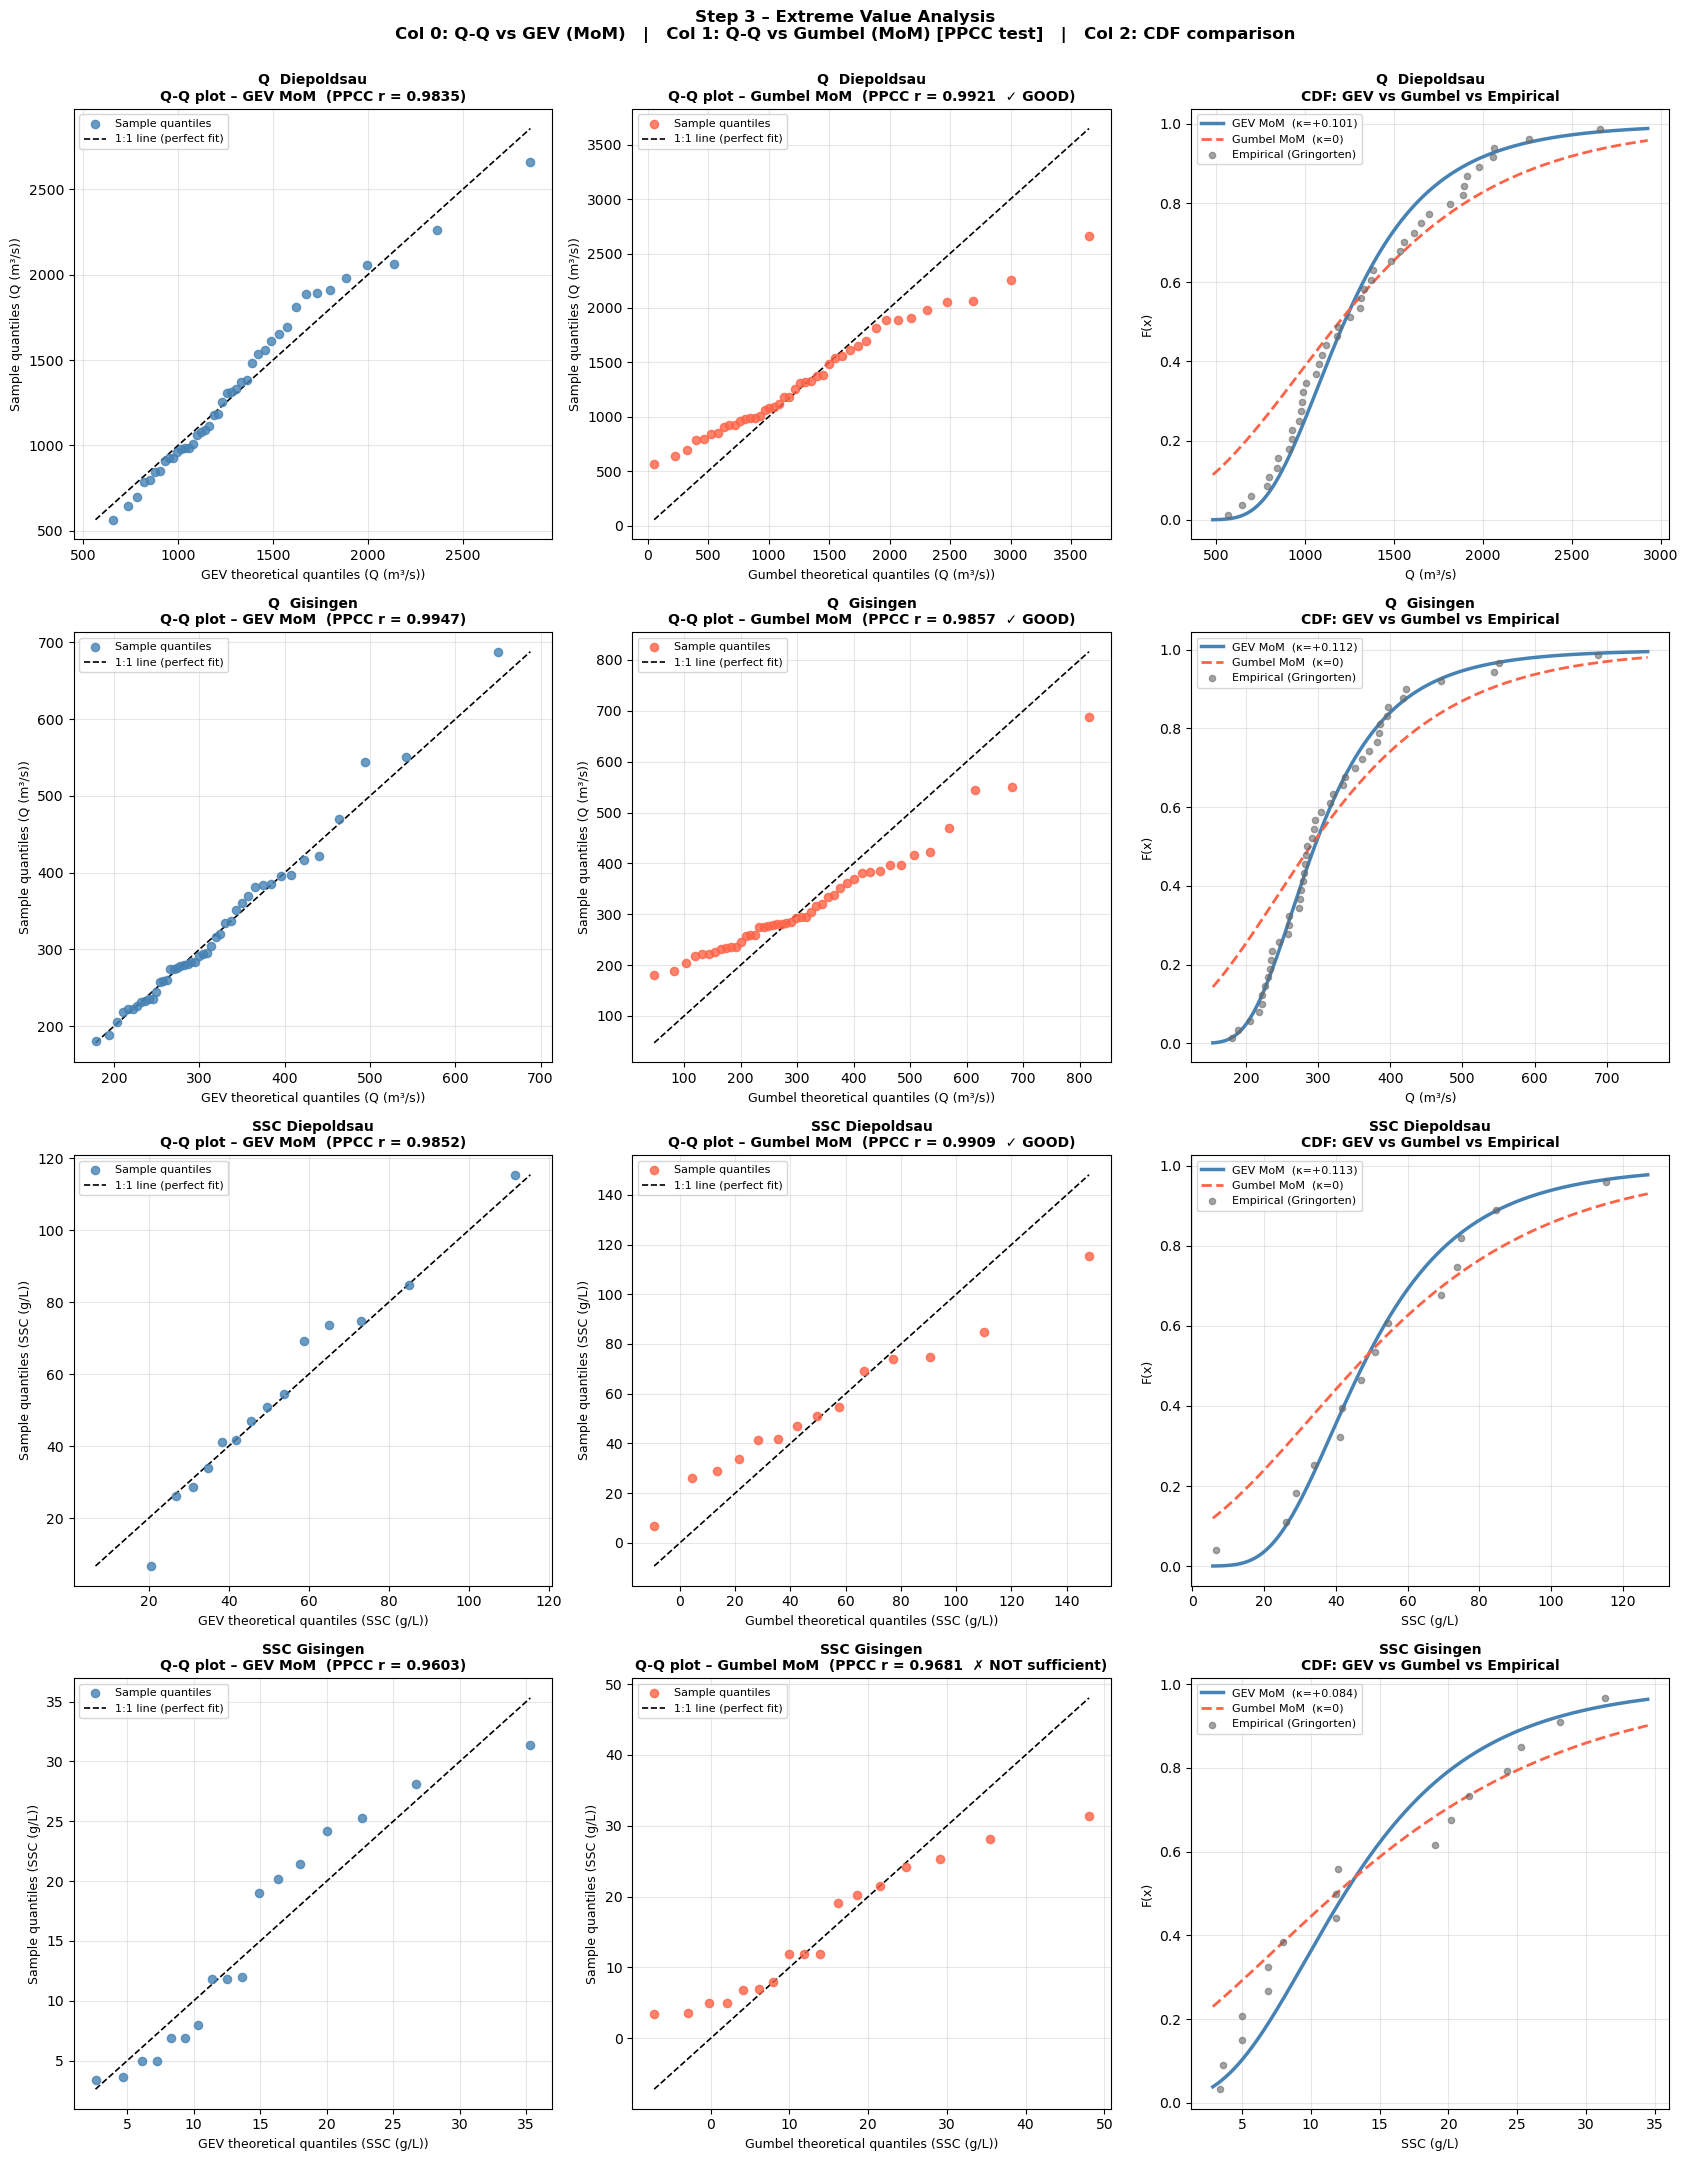

In [18]:
# =============================================================================
# STEP 3 – PLOT
# =============================================================================
# Layout: 4 rows (one per dataset) × 3 columns:
#   col 0 – Q-Q plot: sample quantiles vs GEV theoretical quantiles
#   col 1 – Q-Q plot: sample quantiles vs Gumbel theoretical quantiles (PPCC test)
#   col 2 – CDF comparison: fitted GEV vs fitted Gumbel vs empirical CDF

dataset_list = [
    ('Q  Diepoldsau',  q_d_max,   'Q (m³/s)'),
    ('Q  Gisingen',    q_g_max,   'Q (m³/s)'),
    ('SSC Diepoldsau', ssc_d_max, 'SSC (g/L)'),
    ('SSC Gisingen',   ssc_g_max, 'SSC (g/L)'),
]

fig, axes = plt.subplots(4, 3, figsize=(17, 22))
fig.suptitle(
    'Step 3 – Extreme Value Analysis\n'
    'Col 0: Q-Q vs GEV (MoM)   |   Col 1: Q-Q vs Gumbel (MoM) [PPCC test]   |   Col 2: CDF comparison',
    fontsize=12, fontweight='bold')

for row, (name, data, unit) in enumerate(dataset_list):
    r  = results[name]           # GEV parameters
    rg = gumbel_results[name]    # Gumbel parameters

    n      = len(data)
    # Gringorten plotting position: p_i = (i - 0.44) / (n + 0.12)
    # Recommended for extreme value distributions (Gringorten 1963)
    p      = (np.arange(1, n+1) - 0.44) / (n + 0.12)
    data_s = np.sort(data)                # sorted sample quantiles

    # Theoretical quantiles at the same plotting positions
    # GEV: uses the MoM-fitted parameters (k, mu, sigma) in scipy convention
    q_gev    = gev.ppf(p, r['k'], loc=r['mu'],  scale=r['sigma'])
    # Gumbel: uses the MoM-fitted parameters (mu, sigma) in scipy convention
    q_gumbel = gumbel_r.ppf(p, loc=rg['mu'], scale=rg['sigma'])

    r_gev    = ppcc_results[name]['gev']
    r_gumbel = ppcc_results[name]['gumbel']

    # ── col 0: Q-Q plot — GEV theoretical vs sample ───────────────────────
    # x-axis: what the GEV model predicts for each rank probability
    # y-axis: what we actually observed
    # Points on the 1:1 line → perfect fit of the GEV
    ax = axes[row, 0]
    ax.scatter(q_gev, data_s, color='steelblue', s=35, alpha=0.8, zorder=3,
               label='Sample quantiles')
    lo, hi = min(q_gev.min(), data_s.min()), max(q_gev.max(), data_s.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='1:1 line (perfect fit)')
    ax.set_xlabel(f'GEV theoretical quantiles ({unit})', fontsize=9)
    ax.set_ylabel(f'Sample quantiles ({unit})', fontsize=9)
    ax.set_title(f'{name}\nQ-Q plot – GEV MoM  (PPCC r = {r_gev:.4f})',
                 fontweight='bold', fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # ── col 1: Q-Q plot — Gumbel theoretical vs sample (PPCC test) ───────
    # This is the key plot for question (a): does the Gumbel adequately
    # describe the data?  If r > 0.98 and points lie close to the 1:1 line,
    # the Gumbel is a good approximation for the fitted GEV.
    verdict = '✓ GOOD' if r_gumbel > PPCC_THRESHOLD else '✗ NOT sufficient'
    ax = axes[row, 1]
    ax.scatter(q_gumbel, data_s, color='tomato', s=35, alpha=0.8, zorder=3,
               label='Sample quantiles')
    lo, hi = min(q_gumbel.min(), data_s.min()), max(q_gumbel.max(), data_s.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='1:1 line (perfect fit)')
    ax.set_xlabel(f'Gumbel theoretical quantiles ({unit})', fontsize=9)
    ax.set_ylabel(f'Sample quantiles ({unit})', fontsize=9)
    ax.set_title(
        f'{name}\nQ-Q plot – Gumbel MoM  (PPCC r = {r_gumbel:.4f}  {verdict})',
        fontweight='bold', fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # ── col 2: CDF comparison — GEV vs Gumbel vs empirical ───────────────
    # Useful for question (b): comparing the two stations' distributions.
    # The GEV (solid) and Gumbel (dashed) lines show the fitted models;
    # the grey dots are the empirical Gringorten plotting positions.
    xs = np.linspace(data_s.min() * 0.85, data_s.max() * 1.1, 300)
    ax = axes[row, 2]
    ax.plot(xs, gev.cdf(xs, r['k'], loc=r['mu'], scale=r['sigma']),
            color='steelblue', lw=2.5, label=f'GEV MoM  (κ={r["kappa"]:+.3f})')
    ax.plot(xs, gumbel_r.cdf(xs, loc=rg['mu'], scale=rg['sigma']),
            color='tomato', lw=2, linestyle='--', label='Gumbel MoM  (κ=0)')
    ax.scatter(data_s, p, color='dimgray', s=20, alpha=0.6, zorder=3,
               label='Empirical (Gringorten)')
    ax.set_xlabel(unit, fontsize=9); ax.set_ylabel('F(x)', fontsize=9)
    ax.set_title(f'{name}\nCDF: GEV vs Gumbel vs Empirical',
                 fontweight='bold', fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [ ]:
# =============================================================================
# STEP 3 – PRINT
# =============================================================================

print('=' * 72)
print('GEV Parameter Estimation — Method of Moments')
print('Source: Wilks (2011), Table 4.6 ')
print('Wilks notation: κ=shape, β=scale, ζ=location')
print('scipy convention for genextreme: c = −κ  (sign reversed)')
print('=' * 72)

for name, r in results.items():
    kap = r['kappa']
    if abs(kap) < 0.01:
        gev_type = 'Gumbel / EV-I   (κ ≈ 0,  exponential tail)'
    elif kap > 0:
        gev_type = 'Fréchet / EV-II  (κ > 0,  heavy/polynomial upper tail)'
    else:
        gev_type = 'Weibull / EV-III (κ < 0,  bounded upper tail)'
    print(f'  {name}')
    print(f'    κ (shape)    = {kap:+.4f}  →  {gev_type}')
    print(f'    ζ (location) = {r["mu"]:.4f}   [shifts distribution along x-axis]')
    print(f'    β (scale)    = {r["sigma"]:.4f}   [controls spread of extremes]')
    print()

print()
print('─── Gumbel MoM parameters ──────────────')
for name, rg in gumbel_results.items():
    print(f'  {name}:  ζ = {rg["mu"]:.4f},  β = {rg["sigma"]:.4f}')

print()
print('─── a) PPCC Test: Is Gumbel a good approximation for the fitted GEV? ──')
print(f'  Threshold: r > {PPCC_THRESHOLD}')
print()
for name, pr in ppcc_results.items():
    verdict = 'GOOD ✓' if pr['gumbel'] > PPCC_THRESHOLD else 'NOT sufficient ✗'
    print(f'  {name}')
    print(f'    PPCC (GEV fitted) = {pr["gev"]:.4f}  [reference: max achievable with fitted GEV]')
    print(f'    PPCC (Gumbel)     = {pr["gumbel"]:.4f}  →  {verdict}')
    print()

print()
print('─── b) Comparison of GEV distributions between stations ───────────────')
for var, nd, ng in [('Q',   'Q  Diepoldsau', 'Q  Gisingen'),
                    ('SSC', 'SSC Diepoldsau', 'SSC Gisingen')]:
    rd, rg_par = results[nd], results[ng]
    print(f'  {var} — Diepoldsau vs Gisingen')
    print(f'    κ (tail type) : {rd["kappa"]:+.4f}  vs  {rg_par["kappa"]:+.4f}')
    print(f'    ζ (location)  : {rd["mu"]:.4f}  vs  {rg_par["mu"]:.4f}')
    print(f'    β (scale)     : {rd["sigma"]:.4f}  vs  {rg_par["sigma"]:.4f}')
    print()

GEV Parameter Estimation — Method of Moments
Source: Wilks (2011), Table 4.6 
Wilks notation: κ=shape, β=scale, ζ=location
scipy convention for genextreme: c = −κ  (sign reversed)
  Q  Diepoldsau
    κ (shape)    = +0.1010  →  Fréchet / EV-II  (κ > 0,  heavy/polynomial upper tail)
    ζ (location) = 1100.3203   [shifts distribution along x-axis]
    β (scale)    = 324.6864   [controls spread of extremes]

  Q  Gisingen
    κ (shape)    = +0.1118  →  Fréchet / EV-II  (κ > 0,  heavy/polynomial upper tail)
    ζ (location) = 269.8460   [shifts distribution along x-axis]
    β (scale)    = 67.1672   [controls spread of extremes]

  SSC Diepoldsau
    κ (shape)    = +0.1129  →  Fréchet / EV-II  (κ > 0,  heavy/polynomial upper tail)
    ζ (location) = 40.6302   [shifts distribution along x-axis]
    β (scale)    = 18.3625   [controls spread of extremes]

  SSC Gisingen
    κ (shape)    = +0.0843  →  Fréchet / EV-II  (κ > 0,  heavy/polynomial upper tail)
    ζ (location) = 10.0852   [shifts d

### Comments – Step 3

- **GEV fitting:** κ close to 0 suggests the Gumbel is appropriate; κ < 0 (Weibull) means there is an upper bound to extremes; κ > 0 (Fréchet) means a heavy tail — very large events are not negligibly rare.
- **QQ-plot:** The Gringorten plotting position was used because it is unbiased for the Gumbel distribution and widely accepted in hydrology. It is recommended for annual maximum series analysis (Lecture 7, 31.03.2026, Stochastic Hydrology, Prof. Dr. Paola Passalacqua)

- **a) PPCC test:** If PPCC(Gumbel) r > 0.98, the Gumbel is statistically acceptable as a simplification of the fitted GEV. The QQ-Plots and the PPCC r show for Q-Diepoldsau, Q-Gisingen and SSC-Diepoldsau a good fit of the Gumble Distribution. For the SSC-Gisingen the Gumble Distribution is not sufficient. 
- **b 1) Comparison Q-Diepoldsau and Q Gisingen:** Both GEV are nearly identical and positive: both are Fréchet/EV-II type, meaning neither has a bounded upper tail. The similarity in κ suggests that extreme flood events are physically similar at both locations, likely driven by the same regional meteorological processing on the Ill/Rhein system. The location (ζ) of Diepoldsau is about four times higher than Gisingen (1100 vs 270 m³/s). This directly reflects that Diepoldsau is the downstream station on the Rhein, which drains a much larger catchment area than the Ill at Gisingen. Diepoldsau has a larger scale (β) (325 vs 67 m³/s), meaning year to year variability in peak discharge is much larger at Diepoldsau. This is expected given the larger catchment. More tributaries contributing means more potential for large compound events.
- **b 2) Comparison SSC-Diepoldsau and SSC Gisingen:** Both shapes (κ) are positive but Diepoldsau has a slightly heavier tail (0.113 vs 0.084). This means Diepoldsau has a greater tendency for extreme sediment concentration events relative to its typical level. This is plausible as the Rhein can mobilize sediment from a larger and more diverse catchment.
the location (ζ) of Diepoldsau is about four times higher (40.6 vs 10.1 g/L), indicating the Rhein carries substantially more suspended sediment in extreme years than the Ill. This could reflect differences in geology, land use, or the role of glacial/alpine sources in the larger Rhein catchment.
The scale (β) of Diepoldsau shows more variability (18.4 vs 6.4 g/L). This is consistent with the larger catchment having more diverse sediment sources and more variable transport dynamics.

## 4. Return Period Estimation

**Variables used in this section**

| Variable | Description |
|---|---|
| `RETURN_PERIODS` | [10, 30, 50, 100, 300] years |
| `return_level_df` | DataFrame: return levels, SE, 90 % CI, extrapolation flag |
| `K_T` | Frequency factor (dimensionless) for return period T |
| `delta` | Dimensionless SE factor δ from Skript Eq. 4.28 |

**Theory — return level and standard error**

**Return level** (Wilks 2011, Eq. 4.56):

$$x_T = F^{-1}\!\left(1 - \frac{1}{T}\right), \qquad p_T = 1 - \frac{1}{T}$$

**Standard error — Gumbel / EV-I, Method of Moments**

Source: **Lecture Stochastic Hydrology Module 2: Frequency Analysis from Prof. Dr. Paola Passalacqua Eq. 4.27–4.28**

$$S(x_T) = \frac{\delta}{\sqrt{n}} \cdot S_X \tag{4.27}$$

where $S_X$ is the sample standard deviation of the annual maxima, $n$ is the record length, and the dimensionless factor $\delta$ is:

$$\delta = \sqrt{1 + 1.1396\,K_T + 1.1\,K_T^2} \tag{4.28}$$

with the **frequency factor** $K_T = \dfrac{x_T - \bar{x}}{S_X}$, i.e. how many standard deviations the return level lies above the sample mean.

**90 % confidence interval**:

$$x_T^{u,l} = x_T \pm S(x_T) \cdot z_{1-\alpha/2}$$

For a 90 % CI: $\alpha = 0.10$, so $z_{1-\alpha/2} = z_{0.95} = 1.645$.

In [13]:
# =============================================================================
# STEP 4 – FUNCTIONS
# =============================================================================

def gev_return_level(k, mu, sigma, T):
    """
    Compute the T-year return level for a fitted GEV distribution.

    The return level x_T is the (1 − 1/T) quantile of the GEV.
    Source: Wilks (2011) Eq. 4.56 / scipy genextreme.ppf().

    Parameters
    ----------
    k, mu, sigma : GEV parameters in scipy convention (k = −κ)
    T            : return period in years
    """
    p_T = 1.0 - 1.0 / T   # non-exceedance probability
    return gev.ppf(p_T, k, loc=mu, scale=sigma)


def gumbel_se_mom(x_T, x_bar, s_x, n):
    """
    Standard error of the Gumbel / EV-I T-year return level estimator
    fitted by the Method of Moments.

    Source: Lecture Notes (Stochastic Hydrology) Eq. 4.27–4.28

    Formula
    -------
        S(x_T) = (δ / √n) · S_X          (Eq. 4.27)

        δ = √(1 + 1.1396·K_T + 1.1·K_T²) (Eq. 4.28)

        K_T = (x_T − x̄) / S_X            (frequency factor)

    where:
        x_T   = T-year return level
        x̄     = sample mean of the annual maxima
        S_X   = sample standard deviation of the annual maxima (ddof=1)
        n     = number of years of record (sample size)

    The frequency factor K_T measures how many standard deviations the
    return level lies above the sample mean — it grows with T, which is
    why SE also grows for longer return periods.

    Parameters
    ----------
    x_T   : return level (scalar or array)
    x_bar : sample mean of annual maxima
    s_x   : sample standard deviation of annual maxima (ddof=1)
    n     : record length (years)

    Returns
    -------
    se : standard error of the T-year return level
    """
    # Frequency factor: dimensionless distance from mean in units of std
    K_T = (x_T - x_bar) / s_x

    # Dimensionless SE factor δ (Eq. 4.28)
    delta = np.sqrt(1.0 + 1.1396 * K_T + 1.1 * K_T**2)

    # Standard error (Eq. 4.27)
    return (delta / np.sqrt(n)) * s_x

In [14]:
# =============================================================================
# STEP 4 – MAIN
# =============================================================================

RETURN_PERIODS = np.array([10, 30, 50, 100, 300], dtype=float)

# z-value for 90 % CI: z_{1-α/2} = z_{0.95} = 1.645  (Skript Eq. 4.26)
Z_90 = norm.ppf(0.95)   # = 1.6449

# Record lengths (number of distinct years in each dataset)
record_len = {
    'Q  Diepoldsau' : int(q_diepoldsau['Year'].nunique()),
    'Q  Gisingen'   : int(q_gisingen['Year'].nunique()),
    'SSC Diepoldsau': int(ssc_diepoldsau['Year'].nunique()),
    'SSC Gisingen'  : int(ssc_gisingen['Year'].nunique()),
}

rows = []
for name, data in datasets.items():
    r  = results[name]        # GEV MoM parameters (for return level)
    n  = record_len[name]

    # Sample statistics of the annual maxima — needed for Eq. 4.27–4.28
    data_clean = data[np.isfinite(data)]
    x_bar = np.mean(data_clean)
    s_x   = np.std(data_clean, ddof=1)   # unbiased std (ddof=1)

    for T in RETURN_PERIODS:
        # ── Return level from the fitted GEV ───────────────────────────────
        # Uses the full 3-parameter GEV (κ, ζ, β) from MoM fit
        x_T = gev_return_level(r['k'], r['mu'], r['sigma'], T)

        # ── Standard error: Skript Eq. 4.27–4.28 ──────────────────────────
        # S(x_T) = (δ / √n) · S_X,  with δ = √(1 + 1.1396·K_T + 1.1·K_T²)
        # K_T = (x_T − x̄) / S_X  (frequency factor)
        # Note: this SE formula is derived for the Gumbel / EV-I (κ = 0)
        # and used here as an approximation for the full GEV.
        se = gumbel_se_mom(x_T, x_bar, s_x, n)

        # ── 90 % Confidence Interval (Skript Eq. 4.26) ────────────────────
        # x_T^{u,l} = x_T ± S(x_T) · z_{0.95}
        ci_lo = x_T - Z_90 * se
        ci_hi = x_T + Z_90 * se

        # Frequency factor K_T stored for inspection
        K_T = (x_T - x_bar) / s_x

        rows.append({
            'Dataset'        : name,
            'Record (yrs)'   : n,
            'T (yr)'         : int(T),
            'Return level'   : round(x_T, 3),
            'K_T'            : round(K_T, 4),
            'delta'          : round(np.sqrt(1.0 + 1.1396*K_T + 1.1*K_T**2), 4),
            'Std error (SE)' : round(se, 3),
            'CI90 lower'     : round(ci_lo, 3),
            'CI90 upper'     : round(ci_hi, 3),
            'Rel. uncert. %' : round(100 * se / abs(x_T), 1),
            'Extrapolation'  : T > n,
        })

return_level_df = pd.DataFrame(rows)

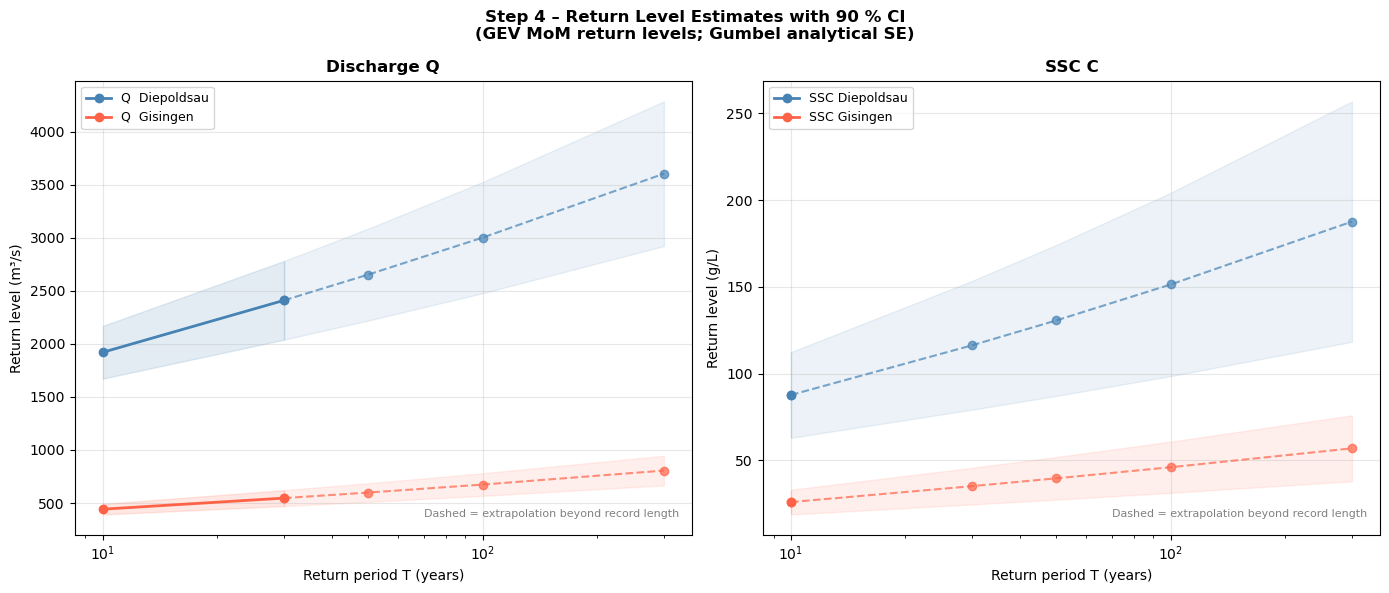

In [19]:
# =============================================================================
# STEP 4 – PLOT
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
fig.suptitle('Step 4 – Return Level Estimates with 90 % CI\n'
             '(GEV MoM return levels; Gumbel analytical SE)',
             fontweight='bold', fontsize=12)

colors = {
    'Q  Diepoldsau' : 'steelblue', 'Q  Gisingen'   : 'tomato',
    'SSC Diepoldsau': 'steelblue', 'SSC Gisingen'  : 'tomato',
}

for name, grp in return_level_df.groupby('Dataset'):
    ax = axes[0] if 'Q ' in name else axes[1]
    lbl = name.strip()

    # --- solid part (within record) ---
    solid  = grp[~grp['Extrapolation']]
    extrap = grp[grp['Extrapolation']]

    ax.plot(solid['T (yr)'], solid['Return level'],
            'o-', color=colors[name], label=lbl, lw=2)
    ax.fill_between(solid['T (yr)'], solid['CI90 lower'], solid['CI90 upper'],
                    color=colors[name], alpha=0.15)

    # --- dashed part (extrapolation), bridged from last solid point ---
    if len(extrap):
        bridge = pd.concat([solid.iloc[[-1]], extrap])   # add last solid point
        ax.plot(bridge['T (yr)'], bridge['Return level'],
                'o--', color=colors[name], lw=1.5, alpha=0.7)
        ax.fill_between(bridge['T (yr)'], bridge['CI90 lower'], bridge['CI90 upper'],
                        color=colors[name], alpha=0.10)

for ax, unit, title in [(axes[0], 'm³/s', 'Discharge Q'),
                         (axes[1], 'g/L',  'SSC C')]:
    ax.set_xscale('log')
    ax.set_xlabel('Return period T (years)')
    ax.set_ylabel(f'Return level ({unit})')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    # Note on extrapolation
    ax.text(0.98, 0.04, 'Dashed = extrapolation beyond record length',
            transform=ax.transAxes, fontsize=8, ha='right', color='grey')

plt.tight_layout()
plt.show()

In [20]:
# =============================================================================
# STEP 4 – PRINT
# =============================================================================

print('Return level estimates: GEV (MoM) quantiles + Gumbel analytical SE')
print('90% CI = return level ± 1.645 × SE  (normal approximation)')
print()
for name, grp in return_level_df.groupby('Dataset'):
    rec = grp['Record (yrs)'].iloc[0]
    print(f'  {name}  (record length: {rec} years)')
    print(grp[['T (yr)', 'Return level', 'Std error (SE)',
               'CI90 lower', 'CI90 upper', 'Rel. uncert. %',
               'Extrapolation']].to_string(index=False))
    print()

print()

Return level estimates: GEV (MoM) quantiles + Gumbel analytical SE
90% CI = return level ± 1.645 × SE  (normal approximation)

  Q  Diepoldsau  (record length: 42 years)
 T (yr)  Return level  Std error (SE)  CI90 lower  CI90 upper  Rel. uncert. %  Extrapolation
     10      1920.641         151.019    1672.236    2169.046             7.9          False
     30      2410.205         225.483    2039.319    2781.091             9.4          False
     50      2653.019         263.448    2219.685    3086.353             9.9           True
    100      3001.295         318.467    2477.463    3525.127            10.6           True
    300      3603.441         414.445    2921.740    4285.142            11.5           True

  Q  Gisingen  (record length: 46 years)
 T (yr)  Return level  Std error (SE)  CI90 lower  CI90 upper  Rel. uncert. %  Extrapolation
     10       441.717          30.275     391.919     491.516             6.9          False
     30       546.156          45.449     47

### Comments – Step 4

- **Standard error and Confidence interval:** Both grow with T. For very large return periods, the return level is a far extrapolation beyond the observed data range and small changes in the fitted parameters produce large changes in the quantile.
- **Record length effect:** (e.g. Q Diepoldsau 42 yr vs SSC Diepoldsau 14 yr) The record length affects the standard error. Shorter records give larger standard error because there is less information to constrain the fit, therfore the estimations of shorter reord lengths are less robust. 
- **Extrapolation:** All T > record length values are model extrapolations. The 300-year level for SSC Diepoldsau is particularly unreliable.

(**Note** The Gumbel analytical standard error is used here as an approximation. It slightly underestimates uncertainty for the full GEV (κ ≠ 0) because it ignores the additional uncertainty in estimating κ)

## 5. Comment on Full Time-Series Analysis

### Core assumptions of frequency analysis (extreme value / GEV)

The GEV Block-Maxima approach rests on two statistical requirements:

1. **Independence:** The observations fed into the GEV must be (approximately) independent of each other.
2. **Identical distribution (i.i.d.):** Each observation must be drawn from the same underlying distribution.

---

### The full sub-hourly series violates both assumptions

If the original time series were used directly, the resulting analysis would be statistically invalid. The approach is problematic because the large number of highly correlated observations within flood events artificially inflates the effective sample size. As a consequence, parameter uncertainty is underestimated and confidence intervals appear unrealistically narrow.

Additionally, the model would be fitted to a mixture of fundamentally different hydrological regimes (e.g. baseflow, snowmelt, and storm runoff), thereby violating the assumption of a common underlying distribution.

In conclusion, using the full sub-hourly time series would treat all observations as independent and identically distributed, and thus estimate the distribution of correlated measurements arising from multiple hydrological processes rather than the distribution of independent extreme flood events.

---
